In [57]:
import torch 
import numpy as np
import torch.nn as nn 
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset

In [58]:
import os
import pandas as pd
from PIL import Image

In [59]:
direct = "/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba/"

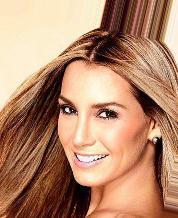

In [60]:
img_path = os.path.join(direct,"000001.jpg" )
Image.open(img_path)

In [61]:
attributes=pd.read_csv("/kaggle/input/celeba-dataset/list_attr_celeba.csv")

In [62]:
attributes.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


In [63]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

In [64]:
class CelebADataset(Dataset):
    def __init__(self, img_dir, attr_file, transform=None):
        self.img_dir = img_dir
        self.attributes = pd.read_csv(attr_file, skiprows=1)
        self.transform=transform

    def __len__(self):
        return len(self.attributes)

    def __getitem__(self, idx):
        img_name = self.attributes.iloc[idx,0]
        img_path = os.path.join(self.img_dir, img_name)
        image=Image.open(img_path).convert('RGB')
        attrs = self.attributes.iloc[idx, 1:].values
        attrs = np.where(attrs == -1, 0, 1).astype(np.float32)
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(attrs)

In [65]:
dataset = CelebADataset(img_dir=direct,
                       attr_file="/kaggle/input/celeba-dataset/list_attr_celeba.csv",
                       transform=transform)

In [66]:
from torch.utils.data import Subset

In [67]:
dataset = Subset(dataset, range(100000))

In [68]:
dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    pin_memory=True
)

In [69]:
print(f"\nDataset size: {len(dataset)}")
print(f"Number of batches: {len(dataloader)}")


Dataset size: 100000
Number of batches: 3125


In [70]:
class VAE(nn.Module):
    def __init__(self,latent_dim):
        super().__init__()
        self.encoder=nn.Sequential(     #batch=32
              nn.Conv2d(3, 32, 4, 2,1), #out: [batch, 32, 32, 32]
              nn.ReLU(),
              nn.Conv2d(32, 64, 4, 2,1), #out: [batch, 64, 16, 16]
              nn.ReLU(),
              nn.Conv2d(64, 128, 4, 2, 1),#out: [batch, 128, 8, 8]
              nn.ReLU(),
        )
        self.flatten = nn.Flatten()
        self.fc_mu= nn.Linear(128*8*8, latent_dim)
        self.fc_logvar = nn.Linear(128*8*8, latent_dim)

        self.fc_decoder = nn.Linear(latent_dim, 128*8*8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),#out: [batch, 64, 16, 16]
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),#out: [batch, 32, 32, 32]
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),#out: [batch, 3, 64, 64] == input_imgae
            nn.Sigmoid(),
        )
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.rand_like(std)
        return mu + eps*std

    def forward(self, x):
        h = self.encoder(x)
        h = self.flatten(h)
        mu = self.fc_mu(h)
        logvar=self.fc_logvar(h)

        z=self.reparameterize(mu, logvar)
        out = self.fc_decoder(z)
        out = out.view(-1, 128, 8, 8)
        out = self.decoder(out)
        return out, mu, logvar        

In [71]:
latent_dim=100
model = VAE(latent_dim)

In [ ]:

model = nn.DataParallel(model)
model.to('cuda')

In [72]:
import torch.nn.functional as F

In [73]:
def vae_loss(out, x, mu, logvar, beta):
    recon_loss = F.mse_loss(out, x, reduction='sum')/x.size(0)
    kl_loss = -0.5*torch.sum((1+logvar-mu.pow(2)-logvar.exp()))/x.size(0)
    total_loss = (recon_loss + beta * kl_loss)
    return total_loss, recon_loss, kl_loss

In [ ]:
for beta in [10,15]:
    model = VAE(latent_dim)
    model = nn.DataParallel(model)
    model.to('cuda')
    optimizer = optim.AdamW(model.parameters(), lr=1e-3)
    print(f"Beta: {beta}")
    for epoch in range(10):
        total_loss=0
        tkl_loss=0
        trecon_loss=0   
        for images, _ in dataloader:
            images=images.to('cuda')
            out, mu, logvar = model(images)
            loss, recon_loss, kl_loss =vae_loss(out, images, mu, logvar, beta=beta)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss+=loss.item()
            tkl_loss+=kl_loss.item()
            trecon_loss+=recon_loss.item()
        avg_loss = total_loss / len(dataloader)
        avg_kl = tkl_loss / len(dataloader)
        avg_recon = trecon_loss / len(dataloader)

        print(f"[+] Epoch {epoch+1}, LOSS: {avg_loss:.2f}| RECON_LOSS: {avg_recon:.2f}| KL_LOSS: {avg_kl:.2f}")
    torch.save(model.state_dict(), f'vae_beta_{beta}.pth')

In [74]:
import matplotlib.pyplot as plt

In [75]:
def latent_traversal(model, latent_dim=100, n_samples=10, range_val=3):
    model.eval()
    fig, axes = plt.subplots(latent_dim, n_samples, figsize=(n_samples*1.5, latent_dim*1.5))

    with torch.no_grad():
        for i in range(latent_dim):
            # Create base latent vector (all zeros)
            base_z = torch.zeros(1, latent_dim)

            # Vary dimension i
            values = torch.linspace(-range_val, range_val, n_samples)
            for j, val in enumerate(values):
                z = base_z.clone()
                z[0, i] = val

                # Decode
                aa = model.fc_decoder(z)
                aa = aa.view(-1, 128, 8, 8)
                x_hat = model.decoder(aa)
                img = x_hat.squeeze(0).permute(1,2,0).cpu().numpy()

                axes[i, j].imshow(img)
                axes[i, j].axis('off')

            axes[i, 0].set_ylabel(f'Dim {i}', rotation=0, labelpad=30)

    plt.tight_layout()
    plt.savefig('latent_traversal.png', dpi=150, bbox_inches='tight')
    plt.show()

In [76]:
model_dir = '/kaggle/input/vae_celeba_models/pytorch/default/1'

In [78]:
all_models = []
for file in os.listdir(model_dir):
    all_models.append(os.path.join(model_dir, file))

In [79]:
all_models

['/kaggle/input/vae_celeba_models/pytorch/default/1/vae_beta_15(1).pth',
 '/kaggle/input/vae_celeba_models/pytorch/default/1/vae_beta_6.pth',
 '/kaggle/input/vae_celeba_models/pytorch/default/1/vae_beta_3.pth',
 '/kaggle/input/vae_celeba_models/pytorch/default/1/vae_beta_0.5(1).pth',
 '/kaggle/input/vae_celeba_models/pytorch/default/1/vae_beta_8.pth',
 '/kaggle/input/vae_celeba_models/pytorch/default/1/vae_beta_1(1).pth',
 '/kaggle/input/vae_celeba_models/pytorch/default/1/vae_beta_10(1).pth']

In [ ]:
model.load_state_dict(new_state_dict)

In [81]:
def load_models_state(path):
    state_dict = torch.load(path, map_location=torch.device('cpu'))
    new_state_dict={}
    for key, value in state_dict.items():
        new_key=key.replace('module.', '')
        new_state_dict[new_key]=value
    return new_state_dict

In [ ]:
for i, path in enumerate(all_models):
    state_dict = load_models_state(path)
    model.load_state_dict(state_dict)
    model_name = all_models[i]
    print(f"Model Name: {model_name[len(model_dir)+1:]}")
    latent_traversal(model)
    print("=======================================")

In [85]:
val = torch.randn(1, latent_dim)

In [97]:
xo = load_models_state(all_models[0])
model.load_state_dict(xo)
model.eval()

VAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_mu): Linear(in_features=8192, out_features=100, bias=True)
  (fc_logvar): Linear(in_features=8192, out_features=100, bias=True)
  (fc_decoder): Linear(in_features=100, out_features=8192, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)

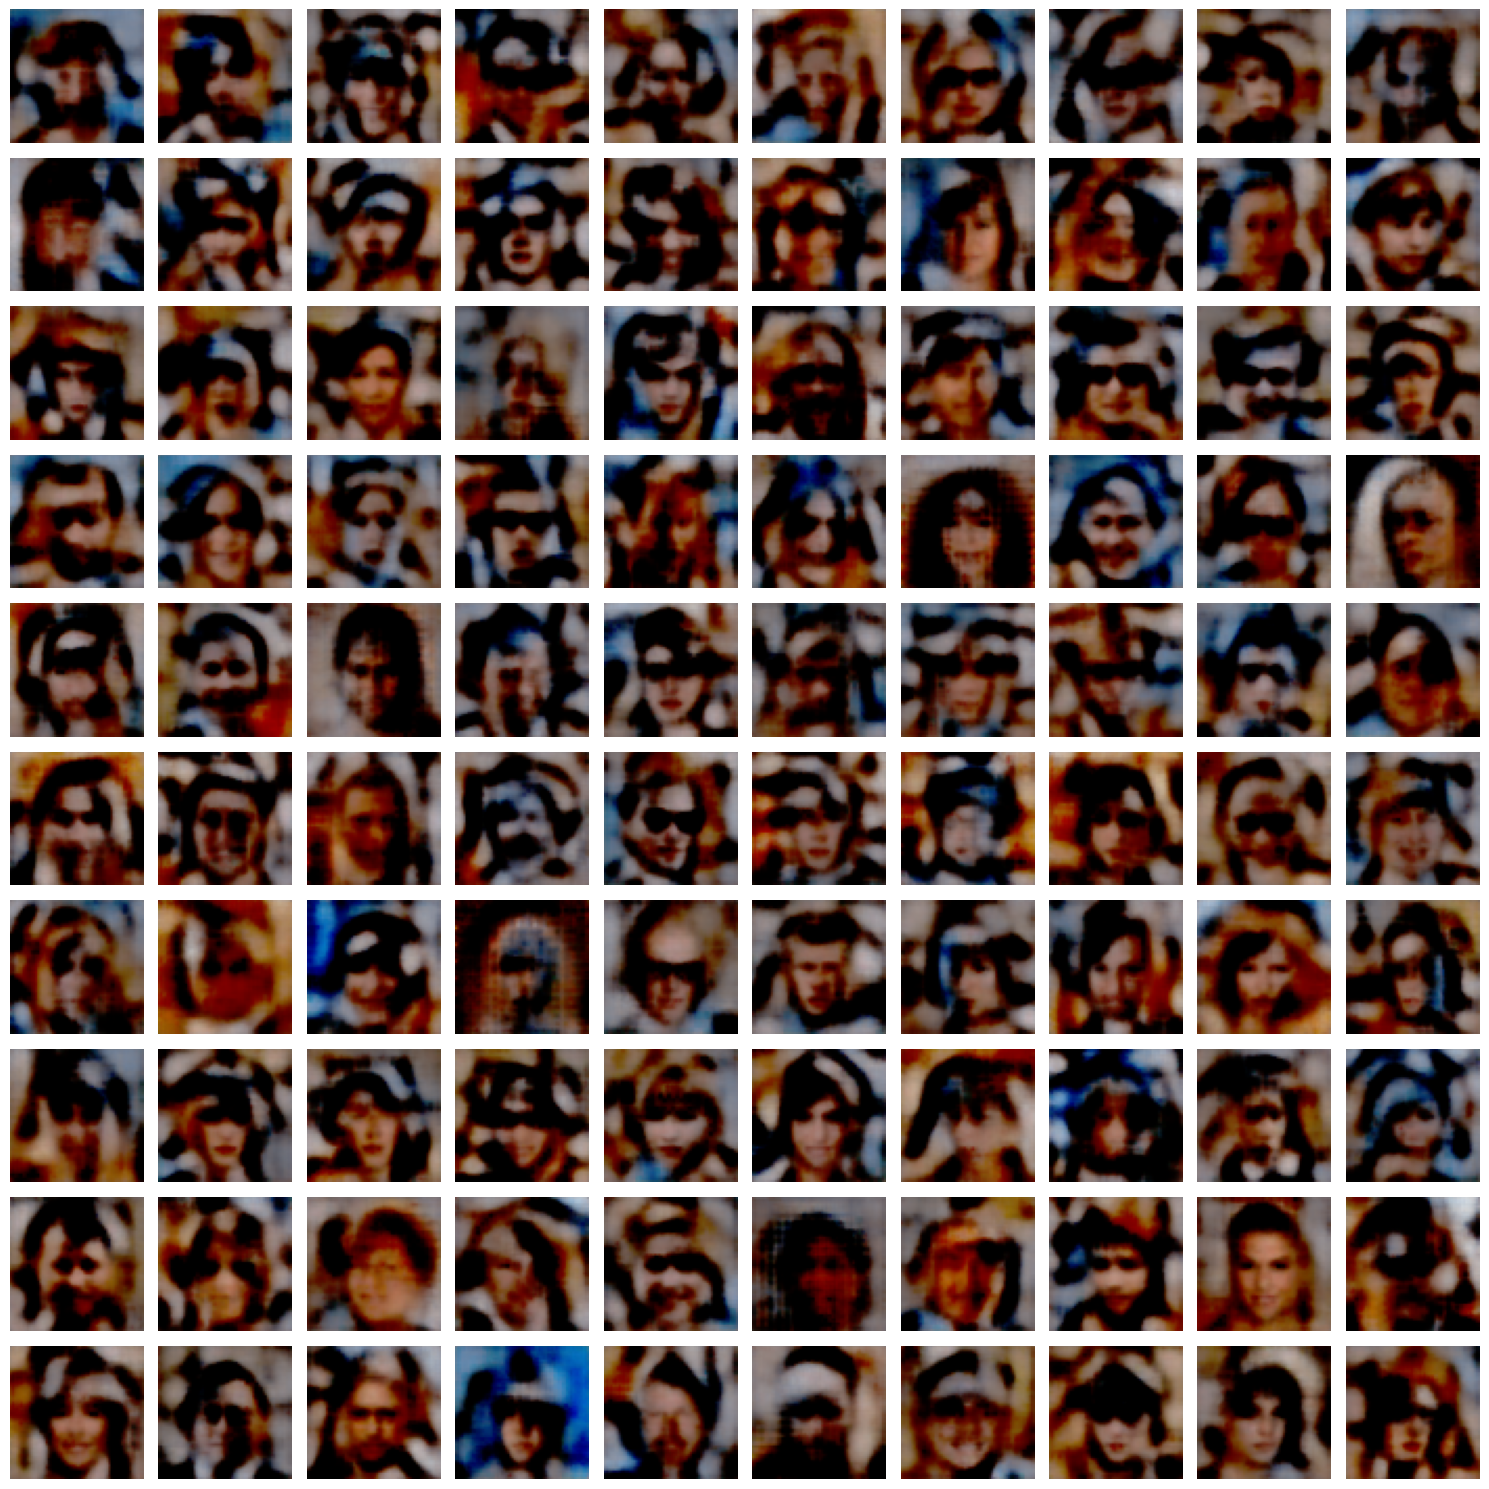

In [98]:
val = 2.0
fig, axes = plt.subplots(10, 10,figsize=(15,15))
base_z= torch.zeros(1, 100)
for i in range(10):
    for j in range(10):
        z=base_z.clone()
        dim=i*10 + j
        z[0, dim] = val
        with torch.no_grad():
            aa = model.fc_decoder(z)
            aa = aa.view(-1, 128, 8, 8)
            out = model.decoder(aa)
    
        img = out.squeeze(0).permute(1,2,0).cpu().numpy()
    
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
plt.tight_layout()
plt.show()

In [110]:
def analyze_latent_statistics(model, data_loader):
    model.eval()
    all_mus = []

    with torch.no_grad():
        for images, _ in data_loader:
            x = model.encoder(images)
            x = model.flatten(x)
            mu = model.fc_mu(x) 
            all_mus.append(mu.cpu())

    all_mus = torch.cat(all_mus, dim=0) 

    # Compute variance and correlation
    variances = all_mus.var(dim=0)
    corr_matrix = torch.corrcoef(all_mus.T)
    return variances, corr_matrix

In [114]:
for i, path in enumerate(all_models):
    model_name=all_models[i]
    print(f"\nModel Name: {model_name[len(model_dir)+1:]}")
    new_state_dict = load_models_state(path)
    model.load_state_dict(new_state_dict)
    variances, corr = analyze_latent_statistics(model, dataloader)

    print(f"Active dimensions (var > 0.1): {(variances > 0.1).sum().item()}")
    print(f"Mean abs correlation: {torch.abs(corr[~torch.eye(20, dtype=bool)]).mean():.3f}")



Model Name: vae_beta_15(1).pth


KeyboardInterrupt: 